# LINCS downstream tasks

LINCS counterpart to `OpenScreen/morphology_expression_downstream_tasks.ipynb`.
Loads the compound-level morphology, expression, and EVPC joint embeddings
written by `lincs_morphology_expression_integration.ipynb` (section 12) from
`LINCS/data/compound_embeddings/` and runs:

1. **Supervised MoA prediction** — nested-CV elastic-net logistic regression +
   MLP on morphology / expression / joint embeddings. 94 A549 compounds,
   23 `moa-fine` classes (many small; only classes with ≥3 members are kept).
2. **Gene-set enrichment prediction** — pseudobulk `lincs_expression_a549.h5ad`
   to score cytotoxic-stress (HSR/UPR) and NF-kB gene sets (seeded by PC1 poles
   in the integration notebook: Dinaciclib/Homoharringtonine pole vs.
   quiescent pole), then nested-CV regress from each embedding.

**Not run here (no A549 equivalent):**
- Tox21 real-time viability: only available for HepG2 — see
  `OpenScreen/morphology_expression_downstream_tasks.ipynb`.
- Probes-drugs target annotation: the `pd_export` annotation table covers
  the OpenScreen HepG2 compound set; no equivalent GTOPDB/multi-label
  annotation is available for the LINCS 94-compound Drug Repurposing Hub
  subset profiled here.

In [1]:
import os
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.stats import spearmanr
from sklearn.linear_model import ElasticNetCV, LogisticRegressionCV
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")
plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"
plt.rcParams["font.size"] = 10

RANDOM_STATE = 0
# Paths relative to repo root (notebook runs from repo root).
EMBEDDING_DIR = "./data/compound_embeddings"
EXPR_H5AD = "./data/lincs_expression_a549.h5ad"

## Load compound-level embeddings

Written by `lincs_morphology_expression_integration.ipynb` section 12:
z-scored morphology PCs, expression PCs, and the equal-variance-contribution
joint concatenation. 94 A549 compounds, 30 PCs each modality.

In [2]:
emb_morph = ad.read_h5ad(f"{EMBEDDING_DIR}/morphology.h5ad")
emb_expr = ad.read_h5ad(f"{EMBEDDING_DIR}/expression.h5ad")
emb_joint = ad.read_h5ad(f"{EMBEDDING_DIR}/joint_evpc.h5ad")

shared_compounds = emb_morph.obs_names.tolist()
for name, adata in (("expression", emb_expr), ("joint_evpc", emb_joint)):
    if set(adata.obs_names) != set(shared_compounds):
        raise ValueError(f"{name}.h5ad compound set does not match morphology.h5ad")

emb_expr = emb_expr[shared_compounds].copy()
emb_joint = emb_joint[shared_compounds].copy()

morph_z = pd.DataFrame(np.asarray(emb_morph.X), index=shared_compounds)
rna_z = pd.DataFrame(np.asarray(emb_expr.X), index=shared_compounds)
joint_z = np.asarray(emb_joint.X)
moa_shared = emb_morph.obs["Metadata_moa_fine"].astype(str)

print(f"morphology: {morph_z.shape}")
print(f"expression: {rna_z.shape}")
print(f"joint EVPC: {joint_z.shape}")
moa_shared.value_counts()

morphology: (86, 30)
expression: (86, 30)
joint EVPC: (86, 60)


Metadata_moa_fine
unclear                            37
DNA synthesis/repair inhibitor     10
Cyclooxygenase inhibitor            6
EGFR/ERBB inhibitor                 4
Androgen receptor antagonist        3
MEK inhibitor                       3
Multi-TK inhibitor                  3
Retinoic receptor agonist           2
HDAC inhibitor                      2
RAF inhibitor                       2
CDK inhibitor                       2
Sonic inhibitor                     2
Proteasome inhibitor                2
DNA methyltransferase inhibitor     1
Glucose transporter inhibitor       1
Protein synthesis inhibitor         1
JAK/STAT inhibitor                  1
GSK3 inhibitor                      1
RAS inhibitor                       1
Microtubule inhibitor               1
Other MAPK inhibitor                1
Name: count, dtype: int64

## Supervised MoA prediction

Drop uncertain labels and classes with fewer than 3 compounds. Nested stratified
CV of elastic-net multinomial logistic regression and a small MLP on
morphology / expression / joint, plus a majority baseline. Report per-MoA
out-of-fold accuracy.

The `moa-fine` annotation covers 23 classes in the LINCS A549 dataset;
most are singletons or pairs, so the supervised set will be a subset of the
94 compounds.

In [3]:
UNCERTAIN_MOA = {"unclear", "uncertain", "unknown", "nan", "none"}
MIN_CLASS_SIZE = 3  # >=1 in a test fold and >=2 in train for inner CV

y_all = moa_shared.astype(str)
labeled = ~y_all.str.lower().isin(UNCERTAIN_MOA)
y_labeled = y_all[labeled]
keep_classes = y_labeled.value_counts()
keep_classes = keep_classes[keep_classes >= MIN_CLASS_SIZE].index
supervised_mask = labeled & y_all.isin(keep_classes)

y_raw = y_all[supervised_mask].to_numpy()
encoder = LabelEncoder()
y = encoder.fit_transform(y_raw)
class_counts = pd.Series(y_raw).value_counts().sort_values(ascending=False)
print(
    f"Supervised MoA set: {len(y)} compounds, {len(encoder.classes_)} classes "
    f"(dropped {(~labeled).sum()} uncertain, "
    f"{(labeled & ~y_all.isin(keep_classes)).sum()} in classes with <{MIN_CLASS_SIZE} members)"
)
print(class_counts.to_string())

spaces: dict[str, np.ndarray] = {
    "morphology": morph_z.to_numpy()[supervised_mask.to_numpy()],
    "expression": rna_z.to_numpy()[supervised_mask.to_numpy()],
    "joint": joint_z[supervised_mask.to_numpy()],
}

n_splits = min(5, int(class_counts.min()))
outer_cv_clf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)


def _inner_cv_clf(y_train: np.ndarray) -> StratifiedKFold:
    min_count = int(np.min(np.bincount(y_train)))
    k = max(2, min(3, min_count))
    return StratifiedKFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)


def fit_elasticnet(X_train: np.ndarray, y_train: np.ndarray) -> LogisticRegressionCV:
    return LogisticRegressionCV(
        penalty="elasticnet",
        solver="saga",
        l1_ratios=[0.15, 0.5, 0.85],
        Cs=8,
        cv=_inner_cv_clf(y_train),
        scoring="f1_macro",
        max_iter=5000,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ).fit(X_train, y_train)


def fit_mlp(X_train: np.ndarray, y_train: np.ndarray) -> MLPClassifier:
    search = GridSearchCV(
        MLPClassifier(
            activation="relu",
            solver="adam",
            max_iter=600,
            random_state=RANDOM_STATE,
        ),
        param_grid={
            "hidden_layer_sizes": [(32,), (64, 32)],
            "alpha": [1e-4, 1e-3],
        },
        cv=_inner_cv_clf(y_train),
        scoring="f1_macro",
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train, y_train)
    return search.best_estimator_


def oof_classify(X: np.ndarray, y: np.ndarray, fit_fn) -> np.ndarray:
    pred = np.empty(len(y), dtype=int)
    for train_idx, test_idx in outer_cv_clf.split(X, y):
        pred[test_idx] = fit_fn(X[train_idx], y[train_idx]).predict(X[test_idx])
    return pred


def majority_baseline_oof(y: np.ndarray) -> np.ndarray:
    pred = np.empty(len(y), dtype=int)
    for train_idx, test_idx in outer_cv_clf.split(np.zeros((len(y), 1)), y):
        counts = np.bincount(y[train_idx], minlength=len(encoder.classes_))
        pred[test_idx] = counts.argmax()
    return pred


row_order = [
    "majority baseline",
    "morphology / elasticnet",
    "morphology / mlp",
    "expression / elasticnet",
    "expression / mlp",
    "joint / elasticnet",
    "joint / mlp",
]
oof_preds: dict[str, np.ndarray] = {}
oof_preds["majority baseline"] = majority_baseline_oof(y)
for space_name, X in spaces.items():
    for model_name, fit_fn in (("elasticnet", fit_elasticnet), ("mlp", fit_mlp)):
        key = f"{space_name} / {model_name}"
        print(f"Fitting {key}...")
        oof_preds[key] = oof_classify(X, y, fit_fn)

# Per-MoA OOF accuracy
moa_class_accuracy = pd.DataFrame(
    index=row_order, columns=sorted(encoder.classes_), dtype=float
)
for row, pred in oof_preds.items():
    for j, cls in enumerate(encoder.classes_):
        mask = y == j
        if mask.sum() > 0:
            moa_class_accuracy.loc[row, cls] = (pred[mask] == y[mask]).mean()

overall = pd.Series(
    {row: (pred == y).mean() for row, pred in oof_preds.items()},
    name="overall_accuracy",
).reindex(row_order)
print("\nOverall OOF accuracy:")
print(overall.round(3).to_string())

Supervised MoA set: 29 compounds, 6 classes (dropped 37 uncertain, 20 in classes with <3 members)
DNA synthesis/repair inhibitor    10
Cyclooxygenase inhibitor           6
EGFR/ERBB inhibitor                4
Androgen receptor antagonist       3
MEK inhibitor                      3
Multi-TK inhibitor                 3
Fitting morphology / elasticnet...
Fitting morphology / mlp...
Fitting expression / elasticnet...
Fitting expression / mlp...
Fitting joint / elasticnet...
Fitting joint / mlp...

Overall OOF accuracy:
majority baseline          0.345
morphology / elasticnet    0.483
morphology / mlp           0.448
expression / elasticnet    0.345
expression / mlp           0.276
joint / elasticnet         0.483
joint / mlp                0.448


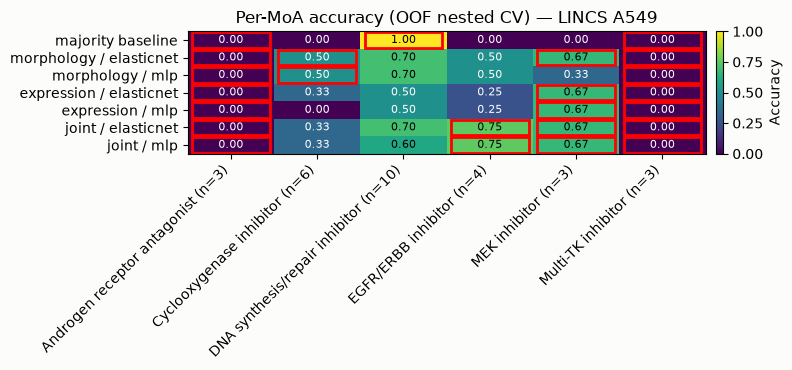

In [4]:
fig, ax = plt.subplots(
    figsize=(max(8, 0.55 * moa_class_accuracy.shape[1] + 3), 3.8)
)
im = ax.imshow(moa_class_accuracy.to_numpy(), aspect="auto", vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(range(moa_class_accuracy.shape[1]))
ax.set_xticklabels(
    [f"{c} (n={int(class_counts[c])})" for c in moa_class_accuracy.columns],
    rotation=45,
    ha="right",
)
ax.set_yticks(range(moa_class_accuracy.shape[0]))
ax.set_yticklabels(moa_class_accuracy.index)
ax.set_title("Per-MoA accuracy (OOF nested CV) — LINCS A549")

highlighted_cells = []
for j in range(moa_class_accuracy.shape[1]):
    col = moa_class_accuracy.iloc[:, j]
    if col.notna().any():
        max_val = np.nanmax(col.values)
        for i in np.where(col.values == max_val)[0]:
            highlighted_cells.append((i, j))

for i in range(moa_class_accuracy.shape[0]):
    for j in range(moa_class_accuracy.shape[1]):
        val = moa_class_accuracy.iloc[i, j]
        if np.isnan(val):
            continue
        ax.text(
            j, i, f"{val:.2f}",
            ha="center", va="center",
            color="white" if val < 0.55 else "black",
            fontsize=8,
        )

for (i, j) in highlighted_cells:
    rect = plt.Rectangle(
        (j - 0.45, i - 0.45), 0.9, 0.9,
        edgecolor="red", linewidth=2, facecolor="none"
    )
    ax.add_patch(rect)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Accuracy")
fig.tight_layout()
plt.show()

## Predict gene-set enrichment (stress axes)

The expression-only UMAP in the LINCS integration notebook splits along PC1
into a **cytotoxic-stress** pole (Dinaciclib, Homoharringtonine, Belinostat,
Decitabine — CDK/HDAC/DNA-synthesis inhibitors with high MDM2/TOP2A) and a
quiescent pole (high IGFBP3/PAPPA). This is the A549 analog of HepG2's
heat-shock / NF-kB split.

Steps:
1. Pseudobulk `lincs_expression_a549.h5ad` to one mean profile per compound.
2. Score gene sets with `scanpy.tl.score_genes`:
   - **`hsr_upr`**: heat-shock / UPR (shared with HepG2 panel; any genes
     absent from the A549 panel are silently dropped).
   - **`nfkb`**: NF-kB / inflammatory signaling.
   - **`cytotox_pc1`**: cytotoxic-stress axis seeded by MDM2, TOP2A, and
     canonical proliferation-stress genes from the LINCS PC1 stressed pole.
3. Nested-CV elastic net + MLP regression from each embedding space.

In [5]:
# Gene sets for A549:
# hsr_upr / nfkb: same as HepG2 (canonically expressed in A549; missing
#   panel members dropped automatically).
# cytotox_pc1: genes driving the cytotoxic-stress PC1 pole in the LINCS
#   integration notebook (MDM2, TOP2A, CDK/replication stress markers).
GENE_SETS: dict[str, list[str]] = {
    "hsr_upr": [
        "HSPA1A", "HSPA1B", "HSPA6", "HSPA8", "HSPA5",
        "HSP90AA1", "HSP90AB1", "HSP90B1", "HSPH1", "HSPB1",
        "DNAJB1", "DNAJA1", "DNAJB4",
        "XBP1", "DDIT3", "ATF4", "ATF6", "ERN1", "HERPUD1", "PPP1R15A",
    ],
    "nfkb": [
        "NFKBIA", "NFKBIE", "NFKB1", "NFKB2", "RELA", "RELB", "REL",
        "TNFAIP3", "BIRC2", "BIRC3", "CYLD", "TRAF1", "TRAF2",
        "CXCL8", "ICAM1", "SOD2",
    ],
    "cytotox_pc1": [
        # Proliferation / DNA-damage checkpoint (stressed pole of PC1):
        "MDM2", "TOP2A", "MKI67", "PCNA", "MCM2", "MCM7",
        "TYMS", "RRM2", "E2F1", "CCNB1", "CDC20", "BUB1",
        # Apoptosis / p53 effectors:
        "BBC3", "PUMA", "PMAIP1", "BAX", "TP53",
        # Cytotoxic-stress (shared with HepG2 heat-shock axis):
        "HMOX1", "SLC7A11", "CHAC1",
    ],
}

rna_cells = ad.read_h5ad(EXPR_H5AD, backed="r")
present = set(rna_cells.var_names)
for name, genes in GENE_SETS.items():
    hit = [g for g in genes if g in present]
    miss = [g for g in genes if g not in present]
    print(f"{name}: {len(hit)}/{len(genes)} genes in panel" + (f" (missing {miss})" if miss else ""))
    GENE_SETS[name] = hit

needed = set().union(*GENE_SETS.values())
rng = np.random.default_rng(RANDOM_STATE)
ctrl_pool = [g for g in rna_cells.var_names if g not in needed]
ctrl = set(rng.choice(ctrl_pool, size=min(500, len(ctrl_pool)), replace=False))
keep_genes_for_score = sorted(needed | ctrl)

print(f"Loading {len(keep_genes_for_score)} genes x {rna_cells.n_obs:,} cells for pseudobulk...")
rna_sub = rna_cells[:, keep_genes_for_score].to_memory()
pb = sc.get.aggregate(rna_sub, by="Metadata_Drug", func="mean")
rna_pb = ad.AnnData(
    np.asarray(pb.layers["mean"]),
    obs=pb.obs.copy(),
    var=pb.var.copy(),
)
if "Metadata_Drug" in rna_pb.obs:
    rna_pb.obs_names = rna_pb.obs["Metadata_Drug"].astype(str).to_numpy()

for name, genes in GENE_SETS.items():
    sc.tl.score_genes(
        rna_pb,
        gene_list=genes,
        score_name=name,
        ctrl_size=50,
        use_raw=False,
        random_state=RANDOM_STATE,
    )

y_geneset = rna_pb.obs[list(GENE_SETS)].reindex(shared_compounds)
print(f"Gene-set scores computed for {y_geneset.notna().all(axis=1).sum()}/{len(shared_compounds)} compounds")
y_geneset.describe()

hsr_upr: 0/20 genes in panel (missing ['HSPA1A', 'HSPA1B', 'HSPA6', 'HSPA8', 'HSPA5', 'HSP90AA1', 'HSP90AB1', 'HSP90B1', 'HSPH1', 'HSPB1', 'DNAJB1', 'DNAJA1', 'DNAJB4', 'XBP1', 'DDIT3', 'ATF4', 'ATF6', 'ERN1', 'HERPUD1', 'PPP1R15A'])
nfkb: 0/16 genes in panel (missing ['NFKBIA', 'NFKBIE', 'NFKB1', 'NFKB2', 'RELA', 'RELB', 'REL', 'TNFAIP3', 'BIRC2', 'BIRC3', 'CYLD', 'TRAF1', 'TRAF2', 'CXCL8', 'ICAM1', 'SOD2'])
cytotox_pc1: 0/20 genes in panel (missing ['MDM2', 'TOP2A', 'MKI67', 'PCNA', 'MCM2', 'MCM7', 'TYMS', 'RRM2', 'E2F1', 'CCNB1', 'CDC20', 'BUB1', 'BBC3', 'PUMA', 'PMAIP1', 'BAX', 'TP53', 'HMOX1', 'SLC7A11', 'CHAC1'])
Loading 0 genes x 0 cells for pseudobulk...


ValueError: Observations annot. `obs` must have as many rows as `X` has rows (542089), but has 0 rows.

In [ ]:
# Nested-CV regression of enrichment scores from each embedding space.
gs_order = [d for d in shared_compounds if d in y_geneset.dropna().index]
y_gs = y_geneset.loc[gs_order]
X_gs: dict[str, np.ndarray] = {
    "morphology": morph_z.loc[gs_order].to_numpy(),
    "expression": rna_z.loc[gs_order].to_numpy(),
    "joint": pd.DataFrame(joint_z, index=shared_compounds).loc[gs_order].to_numpy(),
}
gs_targets = list(y_gs.columns)
print(f"Predicting {gs_targets} for n={len(gs_order)} compounds")

N_OUTER_GS = 5
outer_cv_gs = KFold(n_splits=N_OUTER_GS, shuffle=True, random_state=RANDOM_STATE)
inner_cv_gs = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)


def fit_elasticnet_gs(X_train: np.ndarray, y_train: np.ndarray) -> ElasticNetCV:
    return ElasticNetCV(
        l1_ratio=[0.15, 0.5, 0.85],
        cv=inner_cv_gs,
        max_iter=5000,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ).fit(X_train, y_train)


def fit_mlp_gs(X_train: np.ndarray, y_train: np.ndarray) -> MLPRegressor:
    search = GridSearchCV(
        MLPRegressor(
            activation="relu",
            solver="adam",
            max_iter=800,
            random_state=RANDOM_STATE,
        ),
        param_grid={
            "hidden_layer_sizes": [(32,), (64, 32)],
            "alpha": [1e-4, 1e-3],
        },
        cv=inner_cv_gs,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train, y_train)
    return search.best_estimator_


def oof_regression_gs(X: np.ndarray, y: np.ndarray, fit_fn) -> np.ndarray:
    pred = np.empty(len(y), dtype=float)
    for train_idx, test_idx in outer_cv_gs.split(X):
        pred[test_idx] = fit_fn(X[train_idx], y[train_idx]).predict(X[test_idx])
    return pred


def mean_baseline_oof_gs(y: np.ndarray) -> np.ndarray:
    pred = np.empty(len(y), dtype=float)
    dummy = np.zeros((len(y), 1))
    for train_idx, test_idx in outer_cv_gs.split(dummy):
        pred[test_idx] = y[train_idx].mean()
    return pred


gs_oof: dict[tuple, np.ndarray] = {}
gs_models = [("elasticnet", fit_elasticnet_gs), ("mlp", fit_mlp_gs)]
for space_name, X in X_gs.items():
    for model_name, fit_fn in gs_models:
        for target in gs_targets:
            key = (space_name, model_name, target)
            print(f"Fitting {space_name}/{model_name} -> {target}...")
            gs_oof[key] = oof_regression_gs(X, y_gs[target].to_numpy(), fit_fn)

gs_row_order = [
    "baseline / mean",
    "morphology / elasticnet",
    "morphology / mlp",
    "expression / elasticnet",
    "expression / mlp",
    "joint / elasticnet",
    "joint / mlp",
]

records = []
for target in gs_targets:
    y_true = y_gs[target].to_numpy()
    baseline_pred = mean_baseline_oof_gs(y_true)
    for metric_fn, metric_name in ((spearmanr, "spearman"), (r2_score, "r2"), (mean_absolute_error, "mae")):
        if metric_fn is spearmanr:
            val = metric_fn(y_true, baseline_pred).statistic
        else:
            val = metric_fn(y_true, baseline_pred)
        records.append({"space": "baseline", "model": "mean", "target": target, "metric": metric_name, "value": val})
    for (space_name, model_name, tgt), pred in gs_oof.items():
        if tgt != target:
            continue
        y_pred = pred
        for metric_fn, metric_name in ((spearmanr, "spearman"), (r2_score, "r2"), (mean_absolute_error, "mae")):
            if metric_fn is spearmanr:
                val = metric_fn(y_true, y_pred).statistic
            else:
                val = metric_fn(y_true, y_pred)
            records.append({"space": space_name, "model": model_name, "target": target, "metric": metric_name, "value": val})

geneset_metrics = pd.DataFrame(records)
geneset_spearman = (
    geneset_metrics.loc[geneset_metrics["metric"] == "spearman"]
    .assign(label=lambda d: d["space"] + " / " + d["model"])
    .pivot(index="label", columns="target", values="value")
    .reindex(index=gs_row_order, columns=gs_targets)
)
print("OOF Spearman rho:")
geneset_spearman.round(3)

In [ ]:
# Determine number of subplots: heatmap + one scatter per gene set
n_sets = len(gs_targets)
fig, axes = plt.subplots(1, 1 + n_sets, figsize=(5 + 4.5 * n_sets, 4.0))

im = axes[0].imshow(
    geneset_spearman.to_numpy(), aspect="auto", vmin=-0.2, vmax=1.0, cmap="viridis"
)
axes[0].set_xticks(range(len(geneset_spearman.columns)))
axes[0].set_xticklabels(
    [{"hsr_upr": "HSR/UPR", "nfkb": "NF-kB", "cytotox_pc1": "CytoTox PC1"}.get(c, c)
     for c in geneset_spearman.columns],
    rotation=30,
    ha="right",
)
axes[0].set_yticks(range(len(geneset_spearman.index)))
axes[0].set_yticklabels(geneset_spearman.index)
axes[0].set_title(f"OOF Spearman (n={len(gs_order)}, {N_OUTER_GS}-fold CV)")
for i in range(geneset_spearman.shape[0]):
    for j in range(geneset_spearman.shape[1]):
        val = geneset_spearman.iloc[i, j]
        if np.isnan(val):
            continue
        axes[0].text(
            j, i, f"{val:.2f}",
            ha="center", va="center",
            color="white" if val < 0.4 else "black",
            fontsize=8,
        )
fig.colorbar(im, ax=axes[0], fraction=0.05, pad=0.02).set_label("Spearman rho")

COLORS = {"hsr_upr": "#eb6834", "nfkb": "#2a78d6", "cytotox_pc1": "#1baf7a"}
LABELS = {"hsr_upr": "HSR/UPR", "nfkb": "NF-kB", "cytotox_pc1": "CytoTox PC1"}
for ax, target in zip(axes[1:], gs_targets):
    y_true = y_gs[target].to_numpy()
    y_pred = gs_oof[("joint", "elasticnet", target)]
    ax.scatter(y_true, y_pred, s=18, alpha=0.75, c=COLORS.get(target, "#8c8c8c"))
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], color="gray", ls="--", lw=1)
    ax.set_xlabel("Observed enrichment score")
    ax.set_ylabel("OOF predicted (joint / elasticnet)")
    ax.set_title(LABELS.get(target, target))

fig.tight_layout()
plt.show()

geneset_r2 = (
    geneset_metrics.loc[geneset_metrics["metric"] == "r2"]
    .assign(label=lambda d: d["space"] + " / " + d["model"])
    .pivot(index="label", columns="target", values="value")
    .reindex(index=gs_row_order, columns=gs_targets)
)
print("OOF R2:")
geneset_r2.round(3)